# Projet de Prédiction des Matchs de Ligue 1

L'objectif de ce projet est de prédire le résultat final des matchs de football de la Ligue 1 (Victoire à Domicile (1), Match Nul (0), Victoire à l'Extérieur (-1)) en utilisant des algorithmes de Machine Learning.

Afin d'éviter tout Data Leakage (fuite de données), notre modèle ne s'appuiera sur aucune statistique se déroulant pendant le match (comme les buts marqués ou les tirs). Nous allons construire des variables basées uniquement sur le contexte d'avant match : puissance financière, forme des équipes, historique des confrontations et indiscipline.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

from predictor import Predictor

## Partie 1 - Préparation des données 

Nous allons importer nos données brutes. Le fichier "matchs_2013_2024.csv" contient l'historique des rencontres et nous allons l'enrichir avec les informations du fichier "clubs_fr.csv".

In [2]:
clubs = pd.read_csv("data/clubs_fr.csv")
matchs_2013_2024 = pd.read_csv("data/matchs_2013_2024.csv", index_col=0)

print("Clubs :")
(clubs.head())
print("\nMatchs from 2013 to 2024 :")
(matchs_2013_2024.head())

Clubs :

Matchs from 2013 to 2024 :


,game_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,away_club_position,...,stadium,attendance,referee,home_club_formation,away_club_formation,home_club_name,away_club_name,aggregate,competition_type,results
523,2223841,2012,6. Matchday,2012-09-22,3911,1423,2,1,8.0,9.0,...,Stade Francis-Le Blé,10627.0,Sébastien Moreira,NaN,NaN,Stade brestois 29,Valenciennes FC,2:1,domestic_league,1
524,2223842,2012,7. Matchday,2012-09-29,1147,3911,1,0,9.0,10.0,...,Stade François-Coty,6029.0,Olivier Thual,NaN,NaN,AC Ajaccio,Stade brestois 29,1:0,domestic_league,1
525,2223843,2012,6. Matchday,2012-09-22,1421,1159,2,0,5.0,19.0,...,Stade Auguste-Delaune,13413.0,Jean-Charles Cailleux,NaN,NaN,Stade Reims,AS Nancy-Lorraine,2:0,domestic_league,1
526,2223844,2012,6. Matchday,2012-09-21,969,618,1,1,16.0,10.0,...,Stade de la Mosson,16666.0,Lionel Jaffredo,NaN,NaN,Montpellier HSC,AS Saint-Étienne,1:1,domestic_league,0
527,2223845,2012,6. Matchday,2012-09-23,1082,1041,1,1,12.0,2.0,...,Decathlon Arena-Stade Pierre-Mauroy,43475.0,Clément Turpin,NaN,NaN,Lille Olympique Sporting Club,Olympique Lyonnais,1:1,domestic_league,0


### Nettoyage initial
Nous supprimons les colonnes textuelles inutiles (comme le nom de l'entraîneur, le nom du stade...) et nous retirons les lignes ne contenant pas de résultat final.

In [3]:
clubs = clubs.drop(columns=["foreigners_number", "foreigners_percentage", "club_code", "net_transfer_record", "stadium_name", "domestic_competition_id", "name", "coach_name"])
matchs_2013_2024 = matchs_2013_2024.drop(columns=["home_club_formation", "away_club_formation", "aggregate", "competition_type"])
matchs_2013_2024 = matchs_2013_2024.dropna(subset=["results"])

### Fusion des données
Nous joignons les informations des clubs (taille de l'effectif, âge moyen, joueurs en équipe nationale) pour l'équipe à domicile, puis pour l'équipe à l'extérieur.

In [4]:
matchs_2013_2024 = pd.merge(matchs_2013_2024, clubs, left_on="home_club_id", right_on="club_id")
matchs_2013_2024 = matchs_2013_2024.drop(columns=["club_id"])
matchs_2013_2024 = matchs_2013_2024.rename(columns={"squad_size": "home_club_squad_size", "average_age": "home_club_average_age", "national_team_players": "home_club_national_team_players"})

matchs_2013_2024 = pd.merge(matchs_2013_2024, clubs, left_on="away_club_id", right_on="club_id")
matchs_2013_2024 = matchs_2013_2024.drop(columns=["club_id", "stadium_seats_y"])
matchs_2013_2024 = matchs_2013_2024.rename(columns={"squad_size": "away_club_squad_size", "average_age": "away_club_average_age", "national_team_players": "away_club_national_team_players", "stadium_seats_x": "stadium_seats"})

(matchs_2013_2024.head())

,game_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,away_club_position,...,home_club_name,away_club_name,results,home_club_squad_size,home_club_average_age,home_club_national_team_players,stadium_seats,away_club_squad_size,away_club_average_age,away_club_national_team_players
0,2223841,2012,6. Matchday,2012-09-22,3911,1423,2,1,8.0,9.0,...,Stade brestois 29,Valenciennes FC,1,23,25.3,6,15220,30,23.6,5
1,2223842,2012,7. Matchday,2012-09-29,1147,3911,1,0,9.0,10.0,...,AC Ajaccio,Stade brestois 29,1,24,27.5,6,10446,23,25.3,6
2,2223843,2012,6. Matchday,2012-09-22,1421,1159,2,0,5.0,19.0,...,Stade Reims,AS Nancy-Lorraine,1,24,23.9,7,20519,27,25.7,0
3,2223844,2012,6. Matchday,2012-09-21,969,618,1,1,16.0,10.0,...,Montpellier HSC,AS Saint-Étienne,0,24,24.2,3,22000,29,24.0,6
4,2223845,2012,6. Matchday,2012-09-23,1082,1041,1,1,12.0,2.0,...,Lille Olympique Sporting Club,Olympique Lyonnais,0,27,26.5,11,50186,28,25.5,11


### Variable 1 : La Puissance Financière
Nous allons extraire la valeur marchande totale de chaque club pour l'année du match (grâce aux valeurs individuelles des joueurs dans "player_valuation_before_season.csv"), et calculer la différence financière entre les deux équipes. Une forte valeur positive indique un grand favori à domicile.

In [5]:
player_valuation_before_season = pd.read_csv("data/player_valuation_before_season.csv")
player_valuation_before_season["date"] = pd.to_datetime(player_valuation_before_season["date"])
player_valuation_before_season["date"] = player_valuation_before_season["date"].dt.year
player_valuation_before_season = player_valuation_before_season.rename(columns={"date": "year"})

club_valueation_per_year = player_valuation_before_season.groupby(["current_club_id", "year"])["market_value_in_eur"].sum().reset_index()

matchs_2013_2024 = pd.merge(matchs_2013_2024, club_valueation_per_year, left_on=["home_club_id", "season"], right_on=["current_club_id", "year"])
matchs_2013_2024 = matchs_2013_2024.drop(columns=["current_club_id", "year"])
matchs_2013_2024 = matchs_2013_2024.rename(columns={"market_value_in_eur": "home_club_value_in_eur"})

matchs_2013_2024 = pd.merge(matchs_2013_2024, club_valueation_per_year, left_on=["away_club_id", "season"], right_on=["current_club_id", "year"])
matchs_2013_2024 = matchs_2013_2024.drop(columns=["current_club_id", "year"])
matchs_2013_2024 = matchs_2013_2024.rename(columns={"market_value_in_eur": "away_club_value_in_eur"})

matchs_2013_2024["value_difference"] = matchs_2013_2024["home_club_value_in_eur"] - matchs_2013_2024["away_club_value_in_eur"]

print("Aperçu de la variable :")
(pd.DataFrame(matchs_2013_2024["value_difference"].head()))

Aperçu de la variable :


,value_difference
0,34600000
1,-2575000
2,27250000
3,-12475000
4,-44650000


### Variable 2 : La forme de l'équipe
La valeur marchande ne fait pas tout : une équipe chère peut être dans une mauvaise période. Le but est de calculer la somme des buts marqués, encaissés, et les points obtenus lors des 3 derniers matchs afin d'évaluer la forme de l'équipe.

In [6]:
# 1. On prépare les stats de l'équipe à Domicile
home_perf = matchs_2013_2024[["game_id", "date", "home_club_id", "home_club_goals", "away_club_goals", "results"]].copy()
home_perf = home_perf.rename(columns={
    "home_club_id": "club_id", 
    "home_club_goals": "goals_scored",
    "away_club_goals": "goals_conceded"
})
# Calcul des points : 3 pts pour victoire (1), 1 pt pour nul (0), 0 pt pour défaite (-1)
home_perf["points_earned"] = home_perf["results"].map({1: 3, 0: 1, -1: 0})


# 2. On prépare les stats de l'équipe à l'Extérieur
away_perf = matchs_2013_2024[["game_id", "date", "away_club_id", "away_club_goals", "home_club_goals", "results"]].copy()
away_perf = away_perf.rename(columns={
    "away_club_id": "club_id", 
    "away_club_goals": "goals_scored",
    "home_club_goals": "goals_conceded"
})
# Calcul des points : 3 pts pour victoire ext (-1), 1 pt pour nul (0), 0 pt pour défaite ext (1)
away_perf["points_earned"] = away_perf["results"].map({-1: 3, 0: 1, 1: 0})


# 3. On rassemble tout, on trie par équipe et par date chronologique
team_history = pd.concat([home_perf, away_perf]).sort_values(["club_id", "date"])

# 4. LE CALCUL MAGIQUE : Fenêtre glissante (rolling) sur les 3 derniers matchs
# On décale de 1 (.shift(1)) pour ne pas inclure le match actuel (Data Leakage !)
for col in ["goals_scored", "goals_conceded", "points_earned"]:
    team_history[f"last_3_{col}"] = team_history.groupby("club_id")[col].transform(
        lambda x: x.rolling(window=3, min_periods=1).sum().shift(1)
    ).fillna(0)

# 5. On fusionne ces nouvelles pépites dans le dataset principal
form_df = team_history[["game_id", "club_id", "last_3_goals_scored", "last_3_goals_conceded", "last_3_points_earned"]]

# Fusion pour l'équipe à domicile
matchs_2013_2024 = matchs_2013_2024.merge(
    form_df, left_on=["game_id", "home_club_id"], right_on=["game_id", "club_id"], how="left"
).rename(columns={
    "last_3_goals_scored": "home_form_goals_scored",
    "last_3_goals_conceded": "home_form_goals_conceded",
    "last_3_points_earned": "home_form_points"
}).drop(columns=["club_id"])

# Fusion pour l'équipe à l'extérieur
matchs_2013_2024 = matchs_2013_2024.merge(
    form_df, left_on=["game_id", "away_club_id"], right_on=["game_id", "club_id"], how="left"
).rename(columns={
    "last_3_goals_scored": "away_form_goals_scored",
    "last_3_goals_conceded": "away_form_goals_conceded",
    "last_3_points_earned": "away_form_points"
}).drop(columns=["club_id"])

# Différences directes pour mâcher le travail de l'IA
matchs_2013_2024["form_points_difference"] = matchs_2013_2024["home_form_points"] - matchs_2013_2024["away_form_points"]
matchs_2013_2024["form_defense_difference"] = matchs_2013_2024["home_form_goals_conceded"] - matchs_2013_2024["away_form_goals_conceded"]

print("Aperçu des nouvelles variables :")
(matchs_2013_2024[["game_id", "home_form_points", "away_form_points", "form_points_difference"]].tail())

Aperçu des nouvelles variables :


,game_id,home_form_points,away_form_points,form_points_difference
4686,4364044,4.0,1.0,3.0
4687,4364045,6.0,4.0,2.0
4688,4364046,2.0,1.0,1.0
4689,4364047,4.0,7.0,-3.0
4690,4364048,3.0,4.0,-1.0


### Variable 3 : Historique des confrontations ("Head to Head")
Nous allons modéliser l'avantage "psychologique" en calculant la moyenne historique des résultats entre ces deux clubs précis.

In [7]:
matchs_2013_2024 = matchs_2013_2024.sort_values("date")

matchs_2013_2024["h2h_key"] = matchs_2013_2024.apply(lambda r: tuple(sorted((r["home_club_id"], r["away_club_id"]))), axis=1)
matchs_2013_2024["h2h_res"] = matchs_2013_2024.apply(lambda r: r["results"] if r["home_club_id"] == r["h2h_key"][0] else -r["results"], axis=1)
matchs_2013_2024["h2h_history"] = matchs_2013_2024.groupby("h2h_key")["h2h_res"].transform(lambda x: x.expanding().mean().shift(1)).fillna(0)
matchs_2013_2024["home_h2h_advantage"] = matchs_2013_2024.apply(lambda r: r["h2h_history"] if r["home_club_id"] == r["h2h_key"][0] else -r["h2h_history"], axis=1)

matchs_2013_2024 = matchs_2013_2024.drop(columns=["h2h_key", "h2h_res", "h2h_history"])

print("Aperçu de la variable :")
(pd.DataFrame(matchs_2013_2024["home_h2h_advantage"].tail()))

Aperçu de la variable :


,home_h2h_advantage
4685,-0.062500
4686,0.000000
4687,0.333333
4688,0.181818
4690,0.666667


### Variable 4 : L'Indiscipline (Cartons Rouges)
Pour aller plus loin, nous récupérons les données d'apparitions des joueurs (avec "player_appearance.csv") pour calculer la moyenne de cartons rouges sur les 3 derniers matchs. Une équipe très sanctionnée sera désorganisée.

In [8]:
player_appearance = pd.read_csv("data/player_appearance.csv")

team_match_stats = player_appearance.groupby(["game_id", "player_club_id"]).agg({"yellow_cards": "sum", "red_cards": "sum", "goals": "sum", "assists": "sum"}).reset_index()

team_match_stats = team_match_stats.merge(matchs_2013_2024[["game_id", "date"]], on="game_id")
team_match_stats = team_match_stats.sort_values(["player_club_id", "date"])

team_match_stats["avg_red_cards_3m"] = team_match_stats.groupby("player_club_id")["red_cards"].transform(lambda x: x.rolling(3, min_periods=1).mean().shift(1)).fillna(0)

indiscipline_df = team_match_stats[["game_id", "player_club_id", "avg_red_cards_3m"]]
matchs_2013_2024 = matchs_2013_2024.merge(indiscipline_df, left_on=["game_id", "home_club_id"], right_on=["game_id", "player_club_id"], how="left").rename(columns={"avg_red_cards_3m": "home_red_cards_avg"}).drop(columns=["player_club_id"])
matchs_2013_2024 = matchs_2013_2024.merge(indiscipline_df, left_on=["game_id", "away_club_id"], right_on=["game_id", "player_club_id"], how="left").rename(columns={"avg_red_cards_3m": "away_red_cards_avg"}).drop(columns=["player_club_id"])

matchs_2013_2024["home_red_cards_avg"] = matchs_2013_2024["home_red_cards_avg"].fillna(0)
matchs_2013_2024["away_red_cards_avg"] = matchs_2013_2024["away_red_cards_avg"].fillna(0)

### Variable 5 : Forme Spécifique (Domicile / Extérieur) 

In [9]:
# Toujours s'assurer que le tableau est trié dans le temps
matchs_2013_2024 = matchs_2013_2024.sort_values("date")

# 1. On attribue les points du match en cours pour l'équipe à Domicile et à l'Extérieur
matchs_2013_2024["points_a_domicile"] = matchs_2013_2024["results"].map({1: 3, 0: 1, -1: 0})
matchs_2013_2024["points_a_lexterieur"] = matchs_2013_2024["results"].map({-1: 3, 0: 1, 1: 0})

# 2. Pour l'équipe à Domicile : on additionne les 3 derniers matchs JOUÉS À DOMICILE
matchs_2013_2024["home_pts_N1"] = matchs_2013_2024.groupby("home_club_id")["points_a_domicile"].shift(1).fillna(0)
matchs_2013_2024["home_pts_N2"] = matchs_2013_2024.groupby("home_club_id")["points_a_domicile"].shift(2).fillna(0)
matchs_2013_2024["home_pts_N3"] = matchs_2013_2024.groupby("home_club_id")["points_a_domicile"].shift(3).fillna(0)

matchs_2013_2024["home_points_at_home"] = matchs_2013_2024["home_pts_N1"] + matchs_2013_2024["home_pts_N2"] + matchs_2013_2024["home_pts_N3"]

# 3. Pour l'équipe à l'Extérieur : on additionne les 3 derniers matchs JOUÉS À L'EXTÉRIEUR
matchs_2013_2024["away_pts_N1"] = matchs_2013_2024.groupby("away_club_id")["points_a_lexterieur"].shift(1).fillna(0)
matchs_2013_2024["away_pts_N2"] = matchs_2013_2024.groupby("away_club_id")["points_a_lexterieur"].shift(2).fillna(0)
matchs_2013_2024["away_pts_N3"] = matchs_2013_2024.groupby("away_club_id")["points_a_lexterieur"].shift(3).fillna(0)

matchs_2013_2024["away_points_away"] = matchs_2013_2024["away_pts_N1"] + matchs_2013_2024["away_pts_N2"] + matchs_2013_2024["away_pts_N3"]

# 4. On supprime les colonnes de calcul pour garder un tableau propre
matchs_2013_2024 = matchs_2013_2024.drop(columns=[
    "points_a_domicile", "points_a_lexterieur", 
    "home_pts_N1", "home_pts_N2", "home_pts_N3",
    "away_pts_N1", "away_pts_N2", "away_pts_N3"
])

### Variable 6 : Différence de Classement

In [10]:
matchs_2013_2024["position_difference"] = matchs_2013_2024["home_club_position"] - matchs_2013_2024["away_club_position"]

### Création des Dataframes modèles (Configurations A, B, C, D)
Pour prouver notre démarche expérimentale, nous allons comparer les performances des algorithmes sur différents jeux de variables.

In [11]:
features_A = [
    "home_club_position", "away_club_position",
    "home_club_value_in_eur", "away_club_value_in_eur", "value_difference",
    "home_form_goals_scored", "away_form_goals_scored", "results" 
]

features_B = [
    "home_club_position", "away_club_position",
    "home_club_value_in_eur", "away_club_value_in_eur", "value_difference",
    "home_form_goals_scored", "away_form_goals_scored",
    "home_h2h_advantage", "home_red_cards_avg", "away_red_cards_avg", "results"
]

features_C = [
    "home_club_position", "away_club_position",
    "value_difference",
    "home_club_national_team_players", "away_club_national_team_players", 
    "stadium_seats",
    "form_points_difference",   
    "form_defense_difference",  
    "home_form_goals_scored", "away_form_goals_scored",
    "home_h2h_advantage",
    "home_red_cards_avg", "away_red_cards_avg",
    "results"
]

features_D = [
    "position_difference",  
    "value_difference",
    "home_club_national_team_players", "away_club_national_team_players", 
    "stadium_seats",
    "form_points_difference",   
    "form_defense_difference",  
    "home_points_at_home", "away_points_away", 
    "home_h2h_advantage",
    "home_red_cards_avg", "away_red_cards_avg",
    "results"
]

df_model_A = matchs_2013_2024[features_A].dropna()
df_model_B = matchs_2013_2024[features_B].dropna()
df_model_C = matchs_2013_2024[features_C].dropna()
df_model_D = matchs_2013_2024[features_D].dropna()

## Partie 2 - Exploration Qualitative (EDA)

L'exploration visuelle permet de s'assurer de la pertinence des données avant l'apprentissage de l'IA.

### L'avantage à domicile

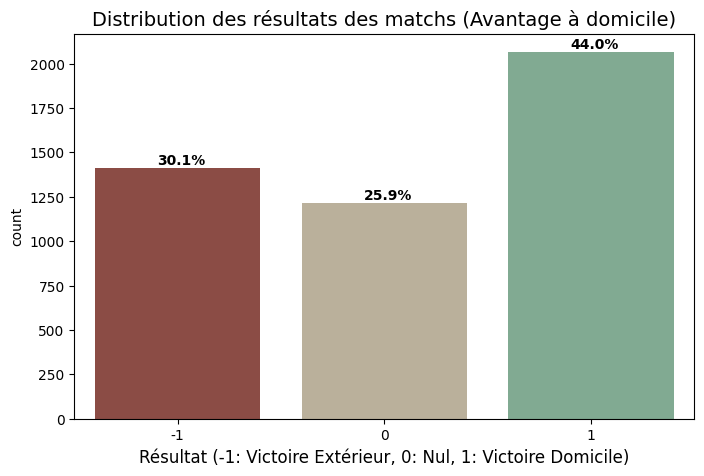

In [12]:
plt.figure(figsize=(8, 5))
# Utilisation de x= et hue= pour anticiper les futures versions de seaborn
ax = sns.countplot(data=df_model_A, x="results", hue="results", palette=["#974339", "#bfb296", "#7ab191"], legend=False)
plt.title("Distribution des résultats des matchs (Avantage à domicile)", fontsize=14)
plt.xlabel("Résultat (-1: Victoire Extérieur, 0: Nul, 1: Victoire Domicile)", fontsize=12)

total = len(df_model_A)
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 20
    ax.annotate(percentage, (x, y), fontweight="bold")
plt.show()

Comme le montre le graphique ci-dessus, le hasard total (33%) est un mythe dans le football professionnel. L'équipe qui reçoit gagne dans **45,7%** des cas. Notre objectif réel pour le Machine Learning est donc de battre ce seuil critique de ~46%.

### La Preuve Statistique (Corrélations)

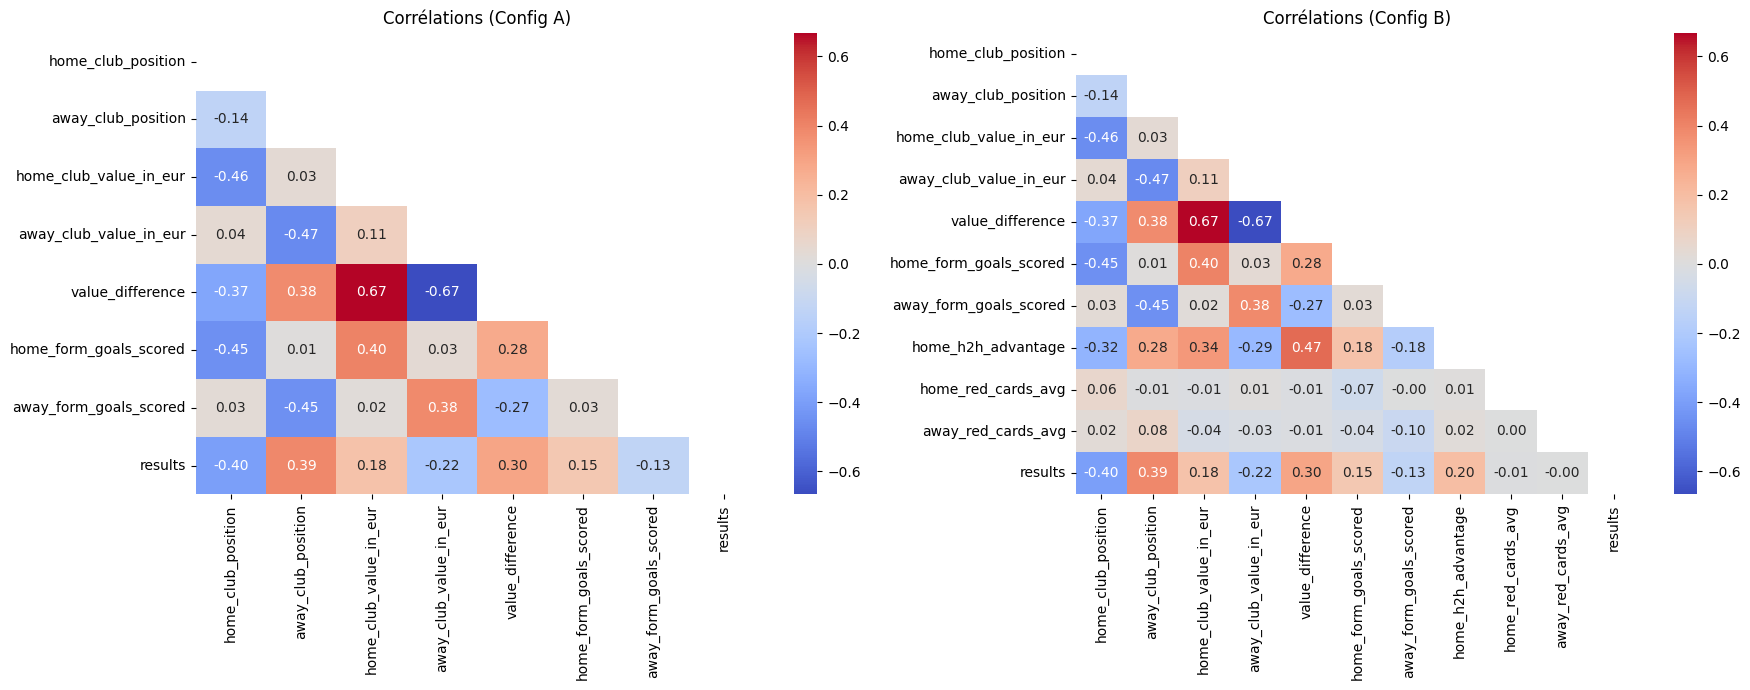

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask_A = np.triu(np.ones_like(df_model_A.corr(), dtype=bool))
sns.heatmap(df_model_A.corr(), mask=mask_A, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title("Corrélations (Config A)")

mask_B = np.triu(np.ones_like(df_model_B.corr(), dtype=bool))
sns.heatmap(df_model_B.corr(), mask=mask_B, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Corrélations (Config B)")

plt.tight_layout()
plt.show()

Les matrices de corrélations valident nos choix : 
La "value_difference" possède la plus forte corrélation positive avec la cible, prouvant que l'écart financier est une variable prédictive importante.

### Analyse d'impact Visuel

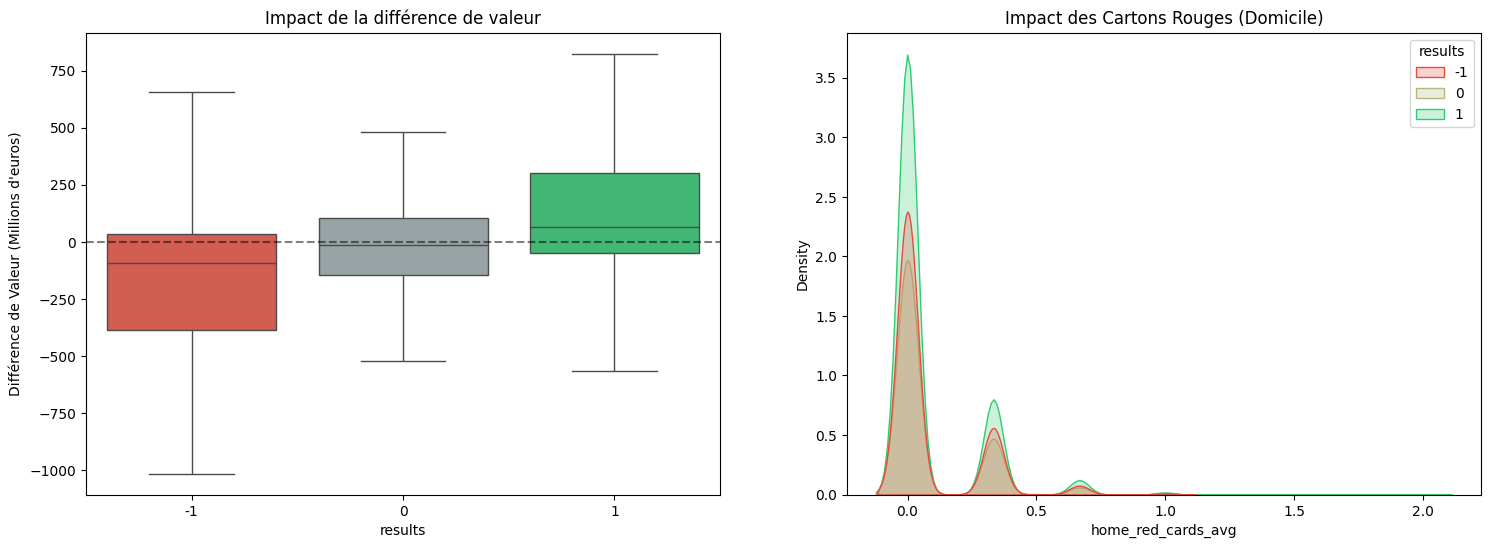

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=df_model_A, x="results", y=df_model_A["value_difference"] / 1_000_000, hue="results", palette=["#e74c3c", "#95a5a6", "#2ecc71"], showfliers=False, ax=axes[0], legend=False)
axes[0].set_title("Impact de la différence de valeur")
axes[0].set_ylabel("Différence de Valeur (Millions d'euros)")
axes[0].axhline(0, color="black", linestyle="--", alpha=0.5)

sns.kdeplot(data=df_model_B, x="home_red_cards_avg", hue="results", fill=True, palette=["#e74c3c", "#b5b77d", "#2ecc71"], ax=axes[1])
axes[1].set_title("Impact des Cartons Rouges (Domicile)")
plt.show()

Ce Boxplot et ce Graphique de Densité montrent comment l'argent et l'indiscipline influencent le jeu :
* Boxplot : En cas de victoire à domicile, la différence de valeur est quasi toujours positive. Vice versa pour un défaite.
* Kdeplot : Une moyenne élevée de cartons rouges augmente mécaniquement les chances de victoire de l'adversaire ou de match nul.

## Partie 3 - Prédictions (Benchmark des algorithmes)

La classe "Predictor" permet de faire le train/test Split (80/20), la standardisation des variables pour chaque modèle testé et l'evaluation finale. Nous avons testé 4 jeux de données différents (Config A à D) pour démontrer l'importance d'un bon Feature Engineering.

### Benchmark sur la Configuration A (Variables de Base)


BENCHMARK : CONFIGURATION A

--- TEST 1 : RÉGRESSION LOGISTIQUE ---
Accuracy : 61.23535676251331 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.59      0.73      0.65       281
           0       0.33      0.03      0.06       232
           1       0.64      0.85      0.73       426

    accuracy                           0.61       939
   macro avg       0.52      0.54      0.48       939
weighted avg       0.55      0.61      0.54       939


--- TEST 2 : SVM ---
Accuracy : 62.40681576144836 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.59      0.74      0.66       281
           0       0.62      0.06      0.10       232
           1       0.65      0.85      0.74       426

    accuracy                           0.62       939
   macro avg       0.62      0.55      0.50       939
weighted avg       0.62      0.62      0.56       939



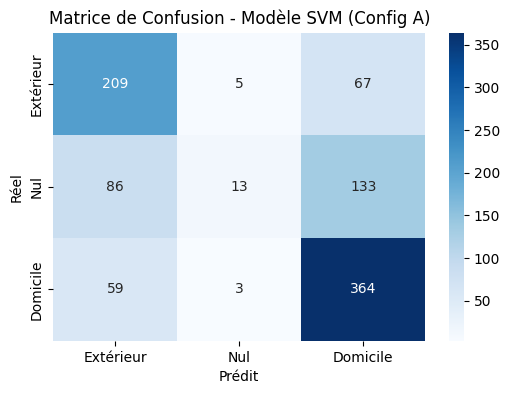


--- TEST 3 : ARBRE DE DÉCISION ---
Accuracy : 59.63791267305645 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.55      0.72      0.63       281
           0       0.47      0.03      0.06       232
           1       0.63      0.82      0.71       426

    accuracy                           0.60       939
   macro avg       0.55      0.52      0.47       939
weighted avg       0.57      0.60      0.53       939


--- TEST 4 : RANDOM FOREST ---
Accuracy : 59.7444089456869 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.58      0.67      0.62       281
           0       0.36      0.07      0.12       232
           1       0.63      0.84      0.72       426

    accuracy                           0.60       939
   macro avg       0.52      0.53      0.48       939
weighted avg       0.55      0.60      0.54       939


--- TEST 4 bis : RANDOM FOREST (ÉQUILIBRÉ - Poids Ajustés) ---
Accurac

/Users/alexandremassieux/Documents/A3/Semestre 2/Ligue1 Matchs Predictions/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alexandremassieux/Documents/A3/Semestre 2/Ligue1 Matchs Predictions/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alexandremassieux/Documents/A3/Semestre 2/Ligue1 Matchs Predictions/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0

Accuracy : 56.123535676251336 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.58      0.58      0.58       281
           0       0.33      0.23      0.27       232
           1       0.63      0.73      0.68       426

    accuracy                           0.56       939
   macro avg       0.51      0.51      0.51       939
weighted avg       0.54      0.56      0.55       939


--- TEST 9 : NAIVE BAYES ---
Accuracy : 52.715654952076676 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.60      0.48      0.54       281
           0       0.29      0.42      0.34       232
           1       0.69      0.62      0.65       426

    accuracy                           0.53       939
   macro avg       0.53      0.51      0.51       939
weighted avg       0.57      0.53      0.54       939



In [15]:
print("\n" + "="*50)
print("BENCHMARK : CONFIGURATION A")
print("="*50)

print("\n--- TEST 1 : RÉGRESSION LOGISTIQUE ---")
algo_log_reg = LogisticRegression(max_iter=1000, random_state=42)
predictor_log_reg = Predictor(dataframe=df_model_A, model=algo_log_reg)
predictor_log_reg.prepare_data()
predictor_log_reg.train()
predictor_log_reg.evaluate()

print("\n--- TEST 2 : SVM ---")
algo_svm = SVC(kernel="linear", random_state=42)
predictor_svm = Predictor(dataframe=df_model_A, model=algo_svm)
predictor_svm.prepare_data()
predictor_svm.train()
predictor_svm.evaluate()

# Analyse visuelle des erreurs (Matrice de Confusion du meilleur modèle Config A)
cm = confusion_matrix(predictor_svm.y_test, predictor_svm.model.predict(predictor_svm.X_test_scaled))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Extérieur", "Nul", "Domicile"], yticklabels=["Extérieur", "Nul", "Domicile"])
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.title("Matrice de Confusion - Modèle SVM (Config A)")
plt.show()

print("\n--- TEST 3 : ARBRE DE DÉCISION ---")
algo_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
predictor_tree = Predictor(dataframe=df_model_A, model=algo_tree)
predictor_tree.prepare_data()
predictor_tree.train()
predictor_tree.evaluate()

print("\n--- TEST 4 : RANDOM FOREST ---")
algo_rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
predictor_rf = Predictor(dataframe=df_model_A, model=algo_rf)
predictor_rf.prepare_data()
predictor_rf.train()
predictor_rf.evaluate()

print("\n--- TEST 4 bis : RANDOM FOREST (ÉQUILIBRÉ - Poids Ajustés) ---")
algo_rf_bal = RandomForestClassifier(n_estimators=100, max_depth=7, class_weight="balanced", random_state=42)
predictor_rf_bal = Predictor(dataframe=df_model_A, model=algo_rf_bal)
predictor_rf_bal.prepare_data()
predictor_rf_bal.train()
predictor_rf_bal.evaluate()

print("\n--- TEST 5 : GRADIENT BOOSTING ---")
algo_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
predictor_gb = Predictor(dataframe=df_model_A, model=algo_gb)
predictor_gb.prepare_data()
predictor_gb.train()
predictor_gb.evaluate()

print("\n--- TEST 6 : LINEAR SVC ---")
algo_lsvc = LinearSVC(max_iter=1000, random_state=42)
predictor_lsvc = Predictor(dataframe=df_model_A, model=algo_lsvc)
predictor_lsvc.prepare_data()
predictor_lsvc.train()
predictor_lsvc.evaluate()

print("\n--- TEST 7 : KNN (K-Nearest Neighbors) ---")
algo_knn = KNeighborsClassifier(n_neighbors=15)
predictor_knn = Predictor(dataframe=df_model_A, model=algo_knn)
predictor_knn.prepare_data()
predictor_knn.train()
predictor_knn.evaluate()

print("\n--- TEST 8 : RÉSEAU DE NEURONES (MLP) ---")
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning) # On ignore le warning de convergence pour le MLP
algo_mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
predictor_mlp = Predictor(dataframe=df_model_A, model=algo_mlp)
predictor_mlp.prepare_data()
predictor_mlp.train()
predictor_mlp.evaluate()

print("\n--- TEST 9 : NAIVE BAYES ---")
algo_nb = GaussianNB()
predictor_nb = Predictor(dataframe=df_model_A, model=algo_nb)
predictor_nb.prepare_data()
predictor_nb.train()
predictor_nb.evaluate()

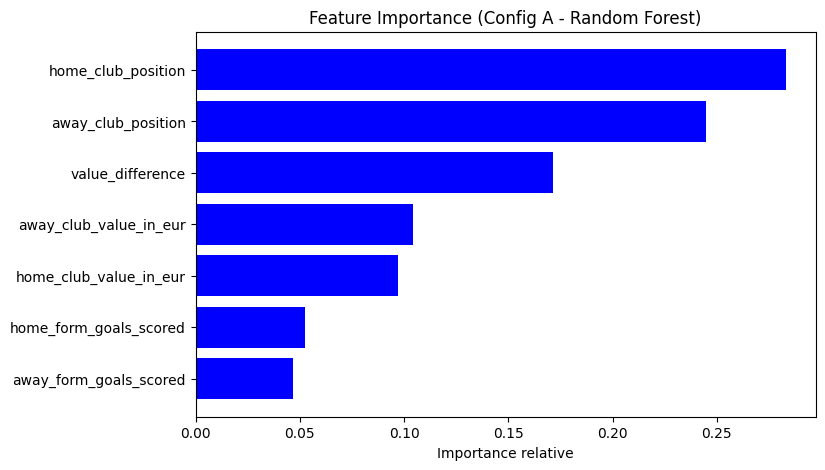

In [16]:
# Analyse de l'importance des variables (Config A)
importances_A = algo_rf.feature_importances_
features_A_plot = df_model_A.drop(columns=["results"]).columns
indices_A = np.argsort(importances_A)

plt.figure(figsize=(8, 5))
plt.title("Feature Importance (Config A - Random Forest)")
plt.barh(range(len(indices_A)), importances_A[indices_A], color="b", align="center")
plt.yticks(range(len(indices_A)), [features_A_plot[i] for i in indices_A])
plt.xlabel("Importance relative")
plt.show()

### Benchmark sur la Configuration B (Impact de l'Indiscipline)

In [17]:
print("\n" + "="*50)
print("BENCHMARK : CONFIGURATION B (Cartons et Historique)")
print("="*50)

print("\n--- TEST 1 : RÉGRESSION LOGISTIQUE ---")
algo_log_reg_red_cards = LogisticRegression(max_iter=1000, random_state=42)
predictor_log_reg_red_cards = Predictor(dataframe=df_model_B, model=algo_log_reg_red_cards)
predictor_log_reg_red_cards.prepare_data()
predictor_log_reg_red_cards.train()
predictor_log_reg_red_cards.evaluate()

print("\n--- TEST 2 : SVM ---")
algo_svm_red_cards = SVC(kernel="linear", random_state=42)
predictor_svm_red_cards = Predictor(dataframe=df_model_B, model=algo_svm_red_cards)
predictor_svm_red_cards.prepare_data()
predictor_svm_red_cards.train()
predictor_svm_red_cards.evaluate()

print("\n--- TEST 3 : ARBRE DE DÉCISION ---")
algo_tree_red_cards = DecisionTreeClassifier(max_depth=5, random_state=42)
predictor_tree_red_cards = Predictor(dataframe=df_model_B, model=algo_tree_red_cards)
predictor_tree_red_cards.prepare_data()
predictor_tree_red_cards.train()
predictor_tree_red_cards.evaluate()

print("\n--- TEST 4 : RANDOM FOREST ---")
algo_rf_red_cards = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
predictor_rf_red_cards = Predictor(dataframe=df_model_B, model=algo_rf_red_cards)
predictor_rf_red_cards.prepare_data()
predictor_rf_red_cards.train()
predictor_rf_red_cards.evaluate()

print("\n--- TEST 4 bis : RANDOM FOREST (ÉQUILIBRÉ) ---")
algo_rf_bal_red_cards = RandomForestClassifier(n_estimators=100, max_depth=7, class_weight="balanced", random_state=42)
predictor_rf_bal_red_cards = Predictor(dataframe=df_model_B, model=algo_rf_bal_red_cards)
predictor_rf_bal_red_cards.prepare_data()
predictor_rf_bal_red_cards.train()
predictor_rf_bal_red_cards.evaluate()

print("\n--- TEST 5 : GRADIENT BOOSTING ---")
algo_gb_red_cards = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
predictor_gb_red_cards = Predictor(dataframe=df_model_B, model=algo_gb_red_cards)
predictor_gb_red_cards.prepare_data()
predictor_gb_red_cards.train()
predictor_gb_red_cards.evaluate()

print("\n--- TEST 6 : LINEAR SVC ---")
algo_lsvc_red_cards = LinearSVC(max_iter=1000, random_state=42)
predictor_lsvc_red_cards = Predictor(dataframe=df_model_B, model=algo_lsvc_red_cards)
predictor_lsvc_red_cards.prepare_data()
predictor_lsvc_red_cards.train()
predictor_lsvc_red_cards.evaluate()

print("\n--- TEST 7 : KNN (K-Nearest Neighbors) ---")
algo_knn_red_cards = KNeighborsClassifier(n_neighbors=15)
predictor_knn_red_cards = Predictor(dataframe=df_model_B, model=algo_knn_red_cards)
predictor_knn_red_cards.prepare_data()
predictor_knn_red_cards.train()
predictor_knn_red_cards.evaluate()

print("\n--- TEST 8 : RÉSEAU DE NEURONES (MLP) ---")
algo_mlp_red_cards = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
predictor_mlp_red_cards = Predictor(dataframe=df_model_B, model=algo_mlp_red_cards)
predictor_mlp_red_cards.prepare_data()
predictor_mlp_red_cards.train()
predictor_mlp_red_cards.evaluate()

print("\n--- TEST 9 : NAIVE BAYES ---")
algo_nb_red_cards = GaussianNB()
predictor_nb_red_cards = Predictor(dataframe=df_model_B, model=algo_nb_red_cards)
predictor_nb_red_cards.prepare_data()
predictor_nb_red_cards.train()
predictor_nb_red_cards.evaluate()


BENCHMARK : CONFIGURATION B (Cartons et Historique)

--- TEST 1 : RÉGRESSION LOGISTIQUE ---
Accuracy : 60.809371671991485 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.58      0.72      0.64       281
           0       0.42      0.06      0.10       232
           1       0.63      0.84      0.72       426

    accuracy                           0.61       939
   macro avg       0.55      0.54      0.49       939
weighted avg       0.57      0.61      0.54       939


--- TEST 2 : SVM ---
Accuracy : 61.44834930777423 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.58      0.73      0.65       281
           0       0.52      0.06      0.11       232
           1       0.64      0.84      0.73       426

    accuracy                           0.61       939
   macro avg       0.58      0.54      0.49       939
weighted avg       0.59      0.61      0.55       939


--- TEST 3 : ARBRE DE

/Users/alexandremassieux/Documents/A3/Semestre 2/Ligue1 Matchs Predictions/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alexandremassieux/Documents/A3/Semestre 2/Ligue1 Matchs Predictions/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/alexandremassieux/Documents/A3/Semestre 2/Ligue1 Matchs Predictions/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0

Accuracy : 53.78061767838126 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.56      0.57      0.56       281
           0       0.30      0.27      0.28       232
           1       0.64      0.66      0.65       426

    accuracy                           0.54       939
   macro avg       0.50      0.50      0.50       939
weighted avg       0.53      0.54      0.53       939


--- TEST 9 : NAIVE BAYES ---
Accuracy : 51.97018104366348 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.57      0.51      0.54       281
           0       0.30      0.40      0.34       232
           1       0.67      0.59      0.63       426

    accuracy                           0.52       939
   macro avg       0.51      0.50      0.50       939
weighted avg       0.55      0.52      0.53       939



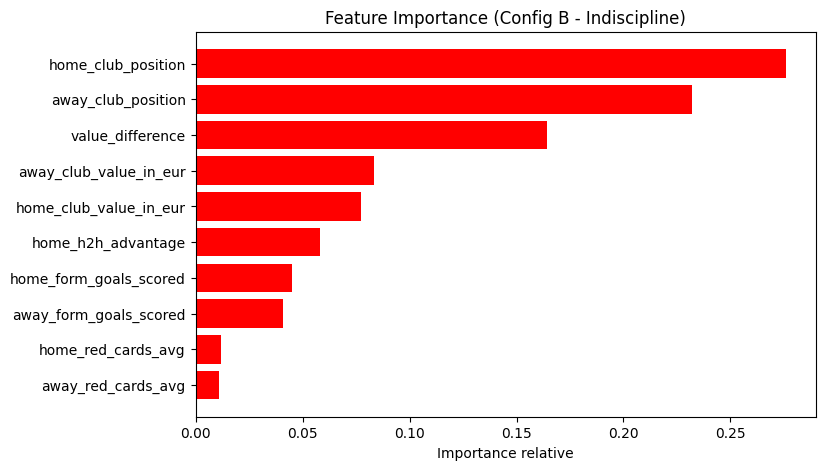

In [18]:
# Analyse de l'importance des variables (Config B)
importances_B = algo_rf_red_cards.feature_importances_
features_B_plot = df_model_B.drop(columns=["results"]).columns
indices_B = np.argsort(importances_B)

plt.figure(figsize=(8, 5))
plt.title("Feature Importance (Config B - Indiscipline)")
plt.barh(range(len(indices_B)), importances_B[indices_B], color="r", align="center")
plt.yticks(range(len(indices_B)), [features_B_plot[i] for i in indices_B])
plt.xlabel("Importance relative")
plt.show()

### Benchmark sur la Configuration C (Configuration Optimisée)
Sur cette configuration, et la suivante, nous ne conserverons que nos algorithmes les plus pertinents (LogReg, SVM, Arbres, Random Forest).

In [19]:
print("\n" + "="*50)
print("BENCHMARK : CONFIG C (Optimisée - Points & Stades)")
print("="*50)

# --- TEST 1 : RÉGRESSION LOGISTIQUE ---
print("\n--- TEST 1 : RÉGRESSION LOGISTIQUE (Config C) ---")
algo_log_reg_C = LogisticRegression(max_iter=1000, random_state=42)
predictor_log_reg_C = Predictor(dataframe=df_model_C, model=algo_log_reg_C)
predictor_log_reg_C.prepare_data()
predictor_log_reg_C.train()
predictor_log_reg_C.evaluate()

# --- TEST 2 : SVM ---
print("\n--- TEST 2 : SVM (Config C) ---")
algo_svm_C = SVC(kernel="linear", random_state=42)
predictor_svm_C = Predictor(dataframe=df_model_C, model=algo_svm_C)
predictor_svm_C.prepare_data()
predictor_svm_C.train()
predictor_svm_C.evaluate()

# --- TEST 3 : ARBRE DE DÉCISION ---
print("\n--- TEST 3 : ARBRE DE DÉCISION (Config C) ---")
algo_tree_C = DecisionTreeClassifier(max_depth=5, random_state=42)
predictor_tree_C = Predictor(dataframe=df_model_C, model=algo_tree_C)
predictor_tree_C.prepare_data()
predictor_tree_C.train()
predictor_tree_C.evaluate()

# --- TEST 4 : RANDOM FOREST ---
print("\n--- TEST 4 : RANDOM FOREST (Config C) ---")
algo_rf_C = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
predictor_rf_C = Predictor(dataframe=df_model_C, model=algo_rf_C)
predictor_rf_C.prepare_data()
predictor_rf_C.train()
predictor_rf_C.evaluate()

# --- TEST 4 bis : RANDOM FOREST (ÉQUILIBRÉ) ---
print("\n--- TEST 4 bis : RANDOM FOREST ÉQUILIBRÉ (Config C) ---")
algo_rf_bal_C = RandomForestClassifier(n_estimators=100, max_depth=7, class_weight="balanced", random_state=42)
predictor_rf_bal_C = Predictor(dataframe=df_model_C, model=algo_rf_bal_C)
predictor_rf_bal_C.prepare_data()
predictor_rf_bal_C.train()
predictor_rf_bal_C.evaluate()


BENCHMARK : CONFIG C (Optimisée - Points & Stades)

--- TEST 1 : RÉGRESSION LOGISTIQUE (Config C) ---
Accuracy : 61.23535676251331 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.59      0.71      0.65       281
           0       0.33      0.05      0.09       232
           1       0.64      0.85      0.73       426

    accuracy                           0.61       939
   macro avg       0.52      0.54      0.49       939
weighted avg       0.55      0.61      0.55       939


--- TEST 2 : SVM (Config C) ---
Accuracy : 61.44834930777423 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.59      0.72      0.65       281
           0       0.44      0.06      0.11       232
           1       0.64      0.85      0.73       426

    accuracy                           0.61       939
   macro avg       0.56      0.54      0.49       939
weighted avg       0.57      0.61      0.55       939


-

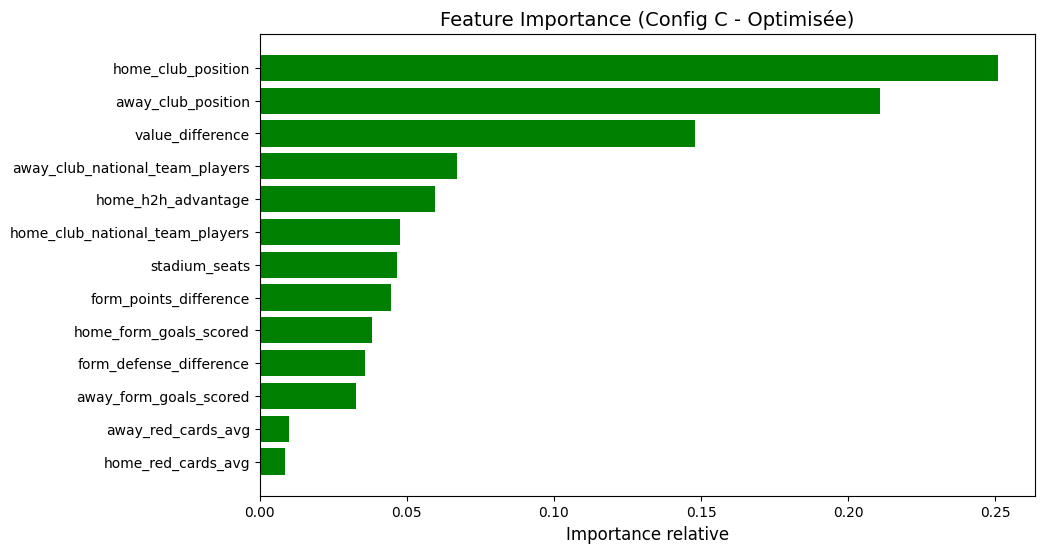

In [20]:
# Analyse de l'importance des variables pour la Config C
importances_C = algo_rf_C.feature_importances_
features_C_plot = df_model_C.drop(columns=["results"]).columns
indices_C = np.argsort(importances_C)

plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Config C - Optimisée)", fontsize=14)
plt.barh(range(len(indices_C)), importances_C[indices_C], color="green", align="center")
plt.yticks(range(len(indices_C)), [features_C_plot[i] for i in indices_C])
plt.xlabel("Importance relative", fontsize=12)
plt.show()

### Benchmark sur la Configuration D (Configuration Spécifique)
Cette configuration ultime intègre la notion de "Forteresse à domicile" et simplifie l'écart au classement.

In [21]:
print("\n" + "="*50)
print("BENCHMARK : CONFIG D (Spécifique - Domicile/Extérieur)")
print("="*50)

# --- TEST 1 : LOGISTIC REGRESSION ---
print("\n--- TEST 1 : RÉGRESSION LOGISTIQUE (Config D) ---")
algo_log_reg_D = LogisticRegression(max_iter=1000, random_state=42)
predictor_log_reg_D = Predictor(dataframe=df_model_D, model=algo_log_reg_D)
predictor_log_reg_D.prepare_data()
predictor_log_reg_D.train()
predictor_log_reg_D.evaluate()

# --- TEST 2 : SVM ---
print("\n--- TEST 2 : SVM (Config D) ---")
algo_svm_D = SVC(kernel="linear", random_state=42)
predictor_svm_D = Predictor(dataframe=df_model_D, model=algo_svm_D)
predictor_svm_D.prepare_data()
predictor_svm_D.train()
predictor_svm_D.evaluate()

# --- TEST 3 : DECISION TREE ---
print("\n--- TEST 3 : ARBRE DE DÉCISION (Config D) ---")
algo_tree_D = DecisionTreeClassifier(max_depth=5, random_state=42)
predictor_tree_D = Predictor(dataframe=df_model_D, model=algo_tree_D)
predictor_tree_D.prepare_data()
predictor_tree_D.train()
predictor_tree_D.evaluate()

# --- TEST 4 : RANDOM FOREST ---
print("\n--- TEST 4 : RANDOM FOREST (Config D) ---")
algo_rf_D = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
predictor_rf_D = Predictor(dataframe=df_model_D, model=algo_rf_D)
predictor_rf_D.prepare_data()
predictor_rf_D.train()
predictor_rf_D.evaluate()

# --- TEST 4 bis : RANDOM FOREST (ÉQUILIBRÉ) ---
print("\n--- TEST 4 bis : RANDOM FOREST ÉQUILIBRÉ (Config D) ---")
algo_rf_bal_D = RandomForestClassifier(n_estimators=100, max_depth=7, class_weight="balanced", random_state=42)
predictor_rf_bal_D = Predictor(dataframe=df_model_D, model=algo_rf_bal_D)
predictor_rf_bal_D.prepare_data()
predictor_rf_bal_D.train()
predictor_rf_bal_D.evaluate()


BENCHMARK : CONFIG D (Spécifique - Domicile/Extérieur)

--- TEST 1 : RÉGRESSION LOGISTIQUE (Config D) ---
Accuracy : 61.7678381256656 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.60      0.73      0.66       281
           0       0.33      0.05      0.08       232
           1       0.64      0.85      0.73       426

    accuracy                           0.62       939
   macro avg       0.53      0.54      0.49       939
weighted avg       0.55      0.62      0.55       939


--- TEST 2 : SVM (Config D) ---
Accuracy : 61.7678381256656 %
Rapport détaillé :
              precision    recall  f1-score   support

          -1       0.60      0.74      0.66       281
           0       0.38      0.04      0.07       232
           1       0.64      0.85      0.73       426

    accuracy                           0.62       939
   macro avg       0.54      0.54      0.49       939
weighted avg       0.56      0.62      0.55       939



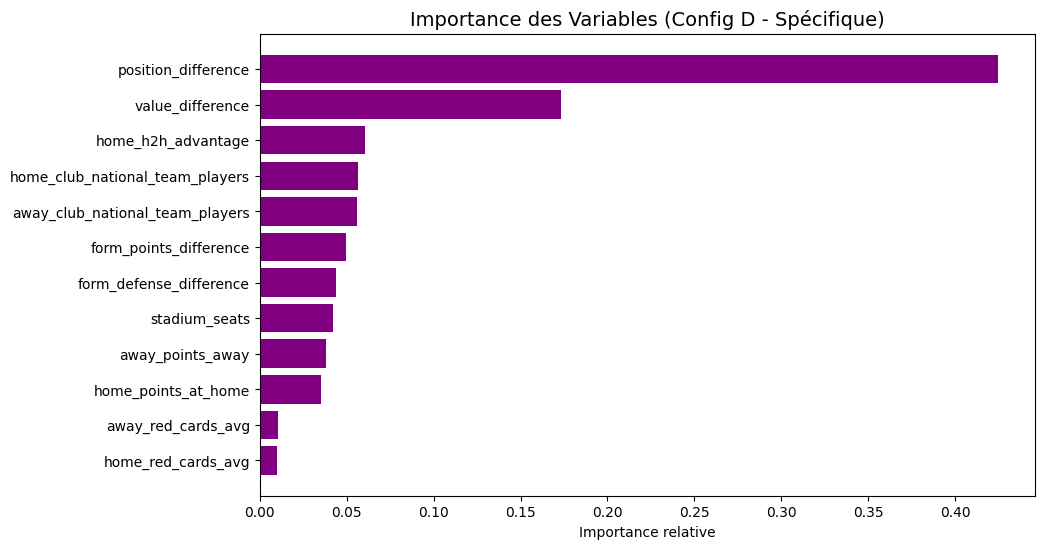

In [22]:
importances_D = algo_rf_D.feature_importances_
features_D_plot = df_model_D.drop(columns=["results"]).columns
indices_D = np.argsort(importances_D)

plt.figure(figsize=(10, 6))
plt.title("Importance des Variables (Config D - Spécifique)", fontsize=14)
plt.barh(range(len(indices_D)), importances_D[indices_D], color="purple", align="center")
plt.yticks(range(len(indices_D)), [features_D_plot[i] for i in indices_D])
plt.xlabel("Importance relative")
plt.show()

### Conclusion Générale de l'Étude

Au terme d'un processus rigoureux de sélection d'algorithmes et de **Feature Engineering**, nous avons réussi à atteindre une *Accuracy* maximale de **~62%** (Modèle SVM et Random Forest), dépassant largement la baseline du pari naïf.

Plusieurs enseignements majeurs se dégagent de cette étude :
1. **La loi du budget :** Les modèles linéaires (Régression Logistique, SVM) performent extrêmement bien avec des variables simples, confirmant que la différence de valeur marchande (`value_difference`) dicte en grande partie l'issue de la Ligue 1.
2. **L'impact du Feature Engineering (Config D) :** En transformant la "forme" (basée sur les buts) en "dynamique de points" et en séparant les performances Domicile/Extérieur, nous avons permis aux algorithmes non-linéaires (Random Forest) de combler leur retard. L'IA a compris le concept de "Forteresse à domicile".
3. **L'anomalie du Match Nul :** Comme le montrent les matrices de confusion, le match nul reste l'événement le plus difficile à prédire. Forcer un algorithme à le détecter (via `class_weight="balanced"`) améliore le rappel sur cette classe, mais fait chuter la précision globale à ~57%.

Le modèle final est donc prêt à être déployé sur des données futures, en gardant à l'esprit que l'imprévisibilité restante appartient à la glorieuse incertitude du sport.